# Mid-Term Project: Multi-Constraint Portfolio Allocation

**Student Name:** Bradley Earl
**Date:** March 13, 2026
**Chosen context:** Automatic Check Processing Cost against General Fund Contributions
**Field:** Unclaimed Property

## Project Overview

You will choose a resource allocation problem in your field, create a synthetic dataset with **8–10 options**, build a **multi-constraint optimization model**, explore **near-optimal alternatives**, run deep sensitivity analysis and validation, then respond to **two stakeholder changes of mind**. The deliverable is one notebook with clear documentation and an executive summary suitable to hand off to a manager.

**Learning Objectives:**
- Build a multi-constraint continuous LP in PuLP (budget cap, category coverage, concentration cap)
- Diagnose and handle infeasibility when constraints interact
- Identify near-optimal alternative solutions and explain why they might be preferred
- Perform sensitivity analysis across 5 parameters at ±20% and ±40%
- Apply extreme value testing and one additional what-if scenario
- Validate the solution with sanity checks and a fragile vs. robust assessment
- Respond to two stakeholder changes of mind with updated models and a three-way comparison
- Communicate findings in an executive summary suitable for a non-technical decision-maker

In [6]:
# Install required packages (if needed in Colab)
# Skip if running locally and packages are already installed
%pip install pulp pandas matplotlib numpy -q

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pulp import LpMaximize, LpMinimize, LpProblem, LpVariable, lpSum, value, LpStatus, PULP_CBC_CMD
import io

print("Libraries imported successfully!")

Libraries imported successfully!


In [8]:
import pandas as pd
import pulp
import io

# Load dataset
csv_data = """option,category,benefit_rate,success_score
Email_Automation,outreach,0.045,82
Case_Management_Upgrade,processing,0.082,91
Public_Notice_Campaign,outreach,0.038,75
OCR_Digitization,processing,0.065,88
Claimant_Portal_UX,search,0.054,79
Data_Matching_Audit,search,0.077,94
Mobile_Search_App,search,0.041,72
Batch_Verification_Tool,processing,0.059,85"""

options_df = pd.read_csv(io.StringIO(csv_data))

# Problem Constants (global variables for the notebook)
budget_total = 120000
min_alloc_per_category = 20000
concentration_cap = 0.30  # 30% of total budget per option

# Derived check value (used later)
max_single_alloc = concentration_cap * budget_total

# ── Display ────────────────────────────────────────────────────────────────────
print(options_df.to_string(index=False))
print(f"\nNumber of options: {len(options_df)}")
print(f"Number of categories: {options_df['category'].nunique()} — {list(options_df['category'].unique())}")
print(f"\nConstraint values:")
print(f"  budget_total           = {budget_total:,}")
print(f"  min_alloc_per_category = {min_alloc_per_category:,}")
print(f"  concentration_cap      = {concentration_cap} (max single option = {max_single_alloc:,.0f})")

# Quick feasibility pre-check
feasibility_ok = (min_alloc_per_category * options_df['category'].nunique() < budget_total) and (max_single_alloc >= min_alloc_per_category)
print(f"\nPre-check: {'✓ Constraint values look feasible' if feasibility_ok else '⚠ WARNING: constraint values may cause immediate infeasibility — adjust before proceeding'}")


                 option   category  benefit_rate  success_score
       Email_Automation   outreach         0.045             82
Case_Management_Upgrade processing         0.082             91
 Public_Notice_Campaign   outreach         0.038             75
       OCR_Digitization processing         0.065             88
     Claimant_Portal_UX     search         0.054             79
    Data_Matching_Audit     search         0.077             94
      Mobile_Search_App     search         0.041             72
Batch_Verification_Tool processing         0.059             85

Number of options: 8
Number of categories: 3 — ['outreach', 'processing', 'search']

Constraint values:
  budget_total           = 120,000
  min_alloc_per_category = 20,000
  concentration_cap      = 0.3 (max single option = 36,000)

Pre-check: ✓ Constraint values look feasible


**Data documentation:** Create a CSV with exactly 8 rows and these exact columns: option (name), category (one of exactly 3 groups — use these names: [outreach, processing, search]), benefit_rate (decimal, between 0.02 to 0.09), success_score (numeric, realistic). Use realistic but simple numbers. Also give me three constraint values: budget_total, min_alloc_per_category, concentration_cap. Output only the CSV and the three values; no other text.  Further, I manually updated the constraints to provide more realistic parameters.

---
## Part 1: Problem Framing and Dataset

### 1.1 Decision Statement

**Decision Statement:**  Having a budget of \$120k to be placed toward various claims processing initiatives in order to better allocate and expend the approved budget appropriations.


### 1.2 Decision Variables vs Inputs

**Decision Variables:** The aim is to determine where to properly allocate budgeted funds towards how best to process claims in our program not to exceed \$120k total and no more than \$36k to a single initiative.

**Inputs:**  Listed out eight categories for claims processing to include benefit and success rate/score as well as budget ceiling along with minimum allocation per category with a constraint to allocate no more than 30% to a single category.

**Explanation:** Utilizing the provided inputs into this model will assist in making an informed decision on where the focus our of program should be and the allocated funding.


### 1.3 Objectives and Constraints

**Objective:**  Determine which claims processing option may provide the maximum value.

**Constraint 1 — Budget Cap (hard):**  The General Assembly has provided appropriations of \$150k towards this effort and it can be extremely difficult to request additional funding.

**Constraint 2 — Category Coverage (hard):**  Our focus categories will each need to receiving some level of funding so that our program is operating at a high but efficient volume.

**Constraint 3 — Concentration Cap (hard):**  Concentration cap to be allocated to a single option cannot exceed 30% of the total budget to ensure overall success of the program should success not be as expected for the option which has been provide the higher portion of funding.


### 1.4 Key Parameters and Uncertainty



In [9]:
import pandas as pd

# Define the data for the 5 parameters
data = {
    "Parameter": [
        "1. Benefit Rate (All)",
        "2. Benefit Rate (Top)",
        "3. budget_total",
        "4. min_alloc_per_category",
        "5. concentration_cap"
    ],
    "Base Value": [
        "0.038 - 0.082",
        "0.082 (Case Mgmt)",
        "120,000",
        "20,000",
        "0.30"
    ],
    "Range (±20%)": [
        "0.0304 - 0.0984",
        "0.0656 - 0.0984",
        "96,000 - 144,000",
        "16,000 - 24,000",
        "0.24 - 0.36"
    ],
    "Impact on Objective (Total Benefit)": [
        "Highest: Direct linear impact on the entire portfolio; a 20% shift changes total benefit by 20%.",
        "High: High volatility because 30% of the budget is concentrated here; a drop triggers a shift to the next best option.",
        "Direct: Controls the scale of the investment; total benefit value scales proportionally with available funds.",
        "Low: Acts as a 'penalty' constraint; increasing this forces more money into the lower-performing 'Outreach' category.",
        "Moderate: A lower cap forces more diversification, reducing total efficiency by limiting spend on top-tier options."
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

# Display as markdown (requires tabulate)
print(df.to_markdown(index=False))


| Parameter                 | Base Value        | Range (±20%)     | Impact on Objective (Total Benefit)                                                                                    |
|:--------------------------|:------------------|:-----------------|:-----------------------------------------------------------------------------------------------------------------------|
| 1. Benefit Rate (All)     | 0.038 - 0.082     | 0.0304 - 0.0984  | Highest: Direct linear impact on the entire portfolio; a 20% shift changes total benefit by 20%.                       |
| 2. Benefit Rate (Top)     | 0.082 (Case Mgmt) | 0.0656 - 0.0984  | High: High volatility because 30% of the budget is concentrated here; a drop triggers a shift to the next best option. |
| 3. budget_total           | 120,000           | 96,000 - 144,000 | Direct: Controls the scale of the investment; total benefit value scales proportionally with available funds.          |
| 4. min_alloc_per_category | 20,000            | 

In [8]:
import pandas as pd
import numpy as np

# Load original data
data = {
    'option': [
        'Case_Management_Upgrade', 'Data_Matching_Audit', 'OCR_Digitization',
        'Batch_Verification_Tool', 'Claimant_Portal_UX', 'Email_Automation',
        'Mobile_Search_App', 'Public_Notice_Campaign'
    ],
    'category': ['processing', 'search', 'processing', 'processing', 'search', 'outreach', 'search', 'outreach'],
    'benefit_rate': [0.082, 0.077, 0.065, 0.059, 0.054, 0.045, 0.041, 0.038],
    'success_score': [91, 94, 88, 85, 79, 82, 72, 75],
    'allocated_budget': [36000, 36000, 12000, 0, 0, 20000, 0, 16000]
}

df = pd.DataFrame(data)

# 1. Define Uncertainty (Standard Deviations)
# Benefit rate SD (15%) and Success score SD (10%)
df['benefit_sd'] = (df['benefit_rate'] * 0.15).round(4)
df['success_sd'] = (df['success_score'] * 0.10).round(2)

# 2. Calculate Expected Weighted Score (Benefit * Success)
df['expected_score'] = (df['benefit_rate'] * df['success_score']).round(3)

# 3. Calculate 95% Confidence Interval
# Propagating uncertainty for a product (A*B):
# Combined Relative SD = sqrt((SD_A/A)^2 + (SD_B/B)^2)
rel_sd_combined = np.sqrt(0.15**2 + 0.10**2)
df['combined_sd'] = (df['expected_score'] * rel_sd_combined).round(3)
df['lower_ci'] = (df['expected_score'] - 1.96 * df['combined_sd']).round(2)
df['upper_ci'] = (df['expected_score'] + 1.96 * df['combined_sd']).round(2)

# 4. Format for display
df['Benefit Rate (±SD)'] = df.apply(lambda x: f"{x['benefit_rate']} ± {x['benefit_sd']}", axis=1)
df['Success Score (±SD)'] = df.apply(lambda x: f"{x['success_score']} ± {x['success_sd']}", axis=1)
df['95% Score Range'] = df.apply(lambda x: f"[{x['lower_ci']}, {x['upper_ci']}]", axis=1)

# Final table assembly
final_table = df[[
    'option', 'category', 'Benefit Rate (±SD)', 'Success Score (±SD)',
    'expected_score', '95% Score Range', 'allocated_budget'
]]

print(final_table.to_string(index=False))


                 option   category Benefit Rate (±SD) Success Score (±SD)  expected_score 95% Score Range  allocated_budget
Case_Management_Upgrade processing     0.082 ± 0.0123            91 ± 9.1           7.462    [4.83, 10.1]             36000
    Data_Matching_Audit     search     0.077 ± 0.0116            94 ± 9.4           7.238     [4.68, 9.8]             36000
       OCR_Digitization processing     0.065 ± 0.0098            88 ± 8.8           5.720     [3.7, 7.74]             12000
Batch_Verification_Tool processing     0.059 ± 0.0088            85 ± 8.5           5.015    [3.24, 6.79]                 0
     Claimant_Portal_UX     search     0.054 ± 0.0081            79 ± 7.9           4.266    [2.76, 5.77]                 0
       Email_Automation   outreach     0.045 ± 0.0068            82 ± 8.2           3.690    [2.39, 4.99]             20000
      Mobile_Search_App     search     0.041 ± 0.0062            72 ± 7.2           2.952    [1.91, 3.99]                 0
 Public_

---
## Part 2: Optimization Model and Near-Optimal Exploration

### 2.1 Build and Solve the Base Model


In [12]:
# ── Base model setup ──────────────────────────────────────────────────────────
n          = len(options_df)
categories = options_df['category'].unique()

# Objective will use the product of benefit_rate and quality_score

model_base = LpProblem("Portfolio_Base", LpMaximize)

# Decision variables: how much to allocate to each option (continuous, ≥ 0)
alloc = [LpVariable(f"alloc_{i}", lowBound=0) for i in range(n)]

# ── Objective ──────────────────────────────────────────────────────────────────
model_base += lpSum([alloc[i] * (options_df.iloc[i]['benefit_rate'] * options_df.iloc[i]['success_score'])
                     for i in range(n)]), "Total_Benefit"

# ── Constraint 1: Budget cap ───────────────────────────────────────────────────
model_base += lpSum(alloc) <= budget_total, "Budget_Cap"

# ── Constraint 2: Category coverage ───────────────────────────────────────────
# Each category must receive at least min_alloc_per_category
for cat in categories:
    cat_idx = options_df.index[options_df['category'] == cat].tolist()
    model_base += (lpSum([alloc[i] for i in cat_idx]) >= min_alloc_per_category,
                   f"Coverage_{cat}")

# ── Constraint 3: Concentration cap ───────────────────────────────────────────
# No single option may receive more than concentration_cap × budget_total
for i in range(n):
    model_base += (alloc[i] <= concentration_cap * budget_total,
                   f"Cap_{options_df.iloc[i, 0]}")

# ── Solve ──────────────────────────────────────────────────────────────────────
model_base.solve(PULP_CBC_CMD(msg=0))

# ── Results ───────────────────────────────────────────────────────────────────
print(f"Status: {LpStatus[model_base.status]}")
print()

if model_base.status == 1:   # Optimal
    base_allocs = [value(alloc[i]) for i in range(n)]
    base_obj    = value(model_base.objective)

    print(f"Objective (total benefit): {base_obj:.4f}")
    print(f"Total allocated: {sum(base_allocs):,.2f}  /  budget: {budget_total:,}")
    print()
    print(f"{'Option':<20} {'Category':<12} {'Allocated':>12} {'% of budget':>12}")
    print("-" * 60)
    for i in range(n):
        opt  = options_df.iloc[i, 0]
        cat  = options_df.iloc[i]['category']
        alloc_val = base_allocs[i]
        pct  = 100 * alloc_val / budget_total
        print(f"{opt:<20} {cat:<12} {alloc_val:>12,.2f} {pct:>11.1f}%")
    print()
    print("Category totals:")
    for cat in categories:
        cat_idx   = options_df.index[options_df['category'] == cat].tolist()
        cat_total = sum(base_allocs[i] for i in cat_idx)
        print(f"  {cat}: {cat_total:,.2f}  (min required: {min_alloc_per_category:,})")

elif model_base.status == -1:  # Infeasible
    print("⚠ INFEASIBLE — see Section 2.2 below for diagnosis and how to relax.")
else:
    print(f"Solver returned status: {LpStatus[model_base.status]}")

Status: Optimal

Objective (total benefit): 763160.0000
Total allocated: 120,000.00  /  budget: 120,000

Option               Category        Allocated  % of budget
------------------------------------------------------------
Email_Automation     outreach        20,000.00        16.7%
Case_Management_Upgrade processing      36,000.00        30.0%
Public_Notice_Campaign outreach             0.00         0.0%
OCR_Digitization     processing      28,000.00        23.3%
Claimant_Portal_UX   search               0.00         0.0%
Data_Matching_Audit  search          36,000.00        30.0%
Mobile_Search_App    search               0.00         0.0%
Batch_Verification_Tool processing           0.00         0.0%

Category totals:
  outreach: 20,000.00  (min required: 20,000)
  processing: 64,000.00  (min required: 20,000)
  search: 36,000.00  (min required: 20,000)


### 2.2 Feasibility Check and Interpretation

**Status:** Optimal.

**Interpretation**
The model determined that four of the eight options would prove to be ideal with Case Management Upgrade and Data Matching Audit receiving equal allocation of 30% of budget or \$36k.  Upgrade systems to improve processes makes logical sense and automation of data matching could prove to reduce manual processing.  Email automation received the lowest allocation of funding which, I suppose, would mean that the return of responses is heavily determinative upon the receiver providing a response to complete the process and would therefore not be as highly reliable of a success rate as the other funded options.

### 2.3 Near-Optimal Alternative 1



In [14]:
# ── Identify the top-allocated option from the base solution ──────────────────
if model_base.status == 1:
    base_allocs  = [value(alloc[i]) for i in range(n)]
    top_idx      = int(np.argmax(base_allocs))
    top_val      = base_allocs[top_idx]
    top_name     = options_df.iloc[top_idx, 0]
    print(f"Top-allocated option in base solution: {top_name}  (${top_val:,.2f})")
    print(f"Capping it at 70% of that value: ${0.70 * top_val:,.2f}")
    print()

    # ── Alternative 1: cap the top option at 70% of its base allocation ────────
    model_alt1   = LpProblem("Portfolio_Alt1", LpMaximize)
    alloc_alt1   = [LpVariable(f"a1_{i}", lowBound=0) for i in range(n)]

    model_alt1  += lpSum([alloc_alt1[i] * (options_df.iloc[i]['benefit_rate'] * options_df.iloc[i]['success_score'])
                          for i in range(n)]), "Total_Benefit"
    model_alt1  += lpSum(alloc_alt1) <= budget_total, "Budget_Cap"
    for cat in categories:
        cat_idx  = options_df.index[options_df['category'] == cat].tolist()
        model_alt1 += (lpSum([alloc_alt1[i] for i in cat_idx]) >= min_alloc_per_category,
                       f"Coverage_{cat}")
    for i in range(n):
        model_alt1 += (alloc_alt1[i] <= concentration_cap * budget_total, f"Cap_{i}")

    # The new constraint: limit the top option
    model_alt1  += alloc_alt1[top_idx] <= 0.70 * top_val, "Alt1_Limit_Top"

    model_alt1.solve(PULP_CBC_CMD(msg=0))
    print(f"Alt 1 Status: {LpStatus[model_alt1.status]}")

    if model_alt1.status == 1:
        alt1_allocs = [value(alloc_alt1[i]) for i in range(n)]
        alt1_obj    = value(model_alt1.objective)
        gap_pct     = 100 * (base_obj - alt1_obj) / base_obj

        print(f"Alt 1 Objective: {alt1_obj:.4f}  (gap from base: {gap_pct:.1f}%)")
        print()
        print(f"{'Option':<20} {'Base':>12} {'Alt 1':>12} {'Δ':>10}")
        print("-" * 58)
        for i in range(n):
            delta = alt1_allocs[i] - base_allocs[i]
            print(f"{options_df.iloc[i,0]:<20} {base_allocs[i]:>12,.2f} "
                  f"{alt1_allocs[i]:>12,.2f} {delta:>+10,.2f}")
    else:
        print("Alt 1 is infeasible with this cap — try a less restrictive limit (e.g. 0.80 instead of 0.70).")
else:
    print("Fix infeasibility in Section 2.1 before running this cell.")

Top-allocated option in base solution: Case_Management_Upgrade  ($36,000.00)
Capping it at 70% of that value: $25,200.00

Alt 1 Status: Optimal
Alt 1 Objective: 742372.4000  (gap from base: 2.7%)

Option                       Base        Alt 1          Δ
----------------------------------------------------------
Email_Automation        20,000.00    20,000.00      +0.00
Case_Management_Upgrade    36,000.00    25,200.00 -10,800.00
Public_Notice_Campaign         0.00         0.00      +0.00
OCR_Digitization        28,000.00    36,000.00  +8,000.00
Claimant_Portal_UX           0.00         0.00      +0.00
Data_Matching_Audit     36,000.00    36,000.00      +0.00
Mobile_Search_App            0.00         0.00      +0.00
Batch_Verification_Tool         0.00     2,800.00  +2,800.00


### 2.3 Near-Optimal Alternative 1

**Alt 1 Outcome:** The top-allocated option from the base solution, `Case_Management_Upgrade`, was capped at 70% of its original allocation (\$25,200.00). This resulted in an objective value of \$742,372.40, representing a `2.7%` gap from the base optimal. The budget shifted, with `OCR_Digitization` increasing its allocation by \$8,000 and `Batch_Verification_Tool` receiving \$2,800 to compensate for the reduction in `Case_Management_Upgrade` while maintaining overall category minimums and the budget cap. This alternative shows a slightly less efficient, but still strong, allocation.

### 2.4 Near-Optimal Alternative 2



In [16]:
# ── Alternative 2: cap the second-highest option ──────────────────────────────
if model_base.status == 1:
    sorted_idx    = sorted(range(n), key=lambda i: base_allocs[i], reverse=True)
    second_idx    = sorted_idx[1]   # second-highest in base solution
    second_val    = base_allocs[second_idx]
    second_name   = options_df.iloc[second_idx, 0]
    print(f"Second-highest option in base: {second_name}  (${second_val:,.2f})")
    print(f"Capping it at 70% of that value: ${0.70 * second_val:,.2f}")
    print()

    model_alt2    = LpProblem("Portfolio_Alt2", LpMaximize)
    alloc_alt2    = [LpVariable(f"a2_{i}", lowBound=0) for i in range(n)]

    model_alt2   += lpSum([alloc_alt2[i] * (options_df.iloc[i]['benefit_rate'] * options_df.iloc[i]['success_score'])
                           for i in range(n)]), "Total_Benefit"
    model_alt2   += lpSum(alloc_alt2) <= budget_total, "Budget_Cap"
    for cat in categories:
        cat_idx   = options_df.index[options_df['category'] == cat].tolist()
        model_alt2 += (lpSum([alloc_alt2[i] for i in cat_idx]) >= min_alloc_per_category,
                       f"Coverage_{cat}")
    for i in range(n):
        model_alt2 += (alloc_alt2[i] <= concentration_cap * budget_total, f"Cap_{i}")

    # The new constraint: limit the second-highest option
    model_alt2   += alloc_alt2[second_idx] <= 0.70 * second_val, "Alt2_Limit_Second"

    model_alt2.solve(PULP_CBC_CMD(msg=0))
    print(f"Alt 2 Status: {LpStatus[model_alt2.status]}")

    if model_alt2.status == 1:
        alt2_allocs = [value(alloc_alt2[i]) for i in range(n)]
        alt2_obj    = value(model_alt2.objective)
        gap_pct2    = 100 * (base_obj - alt2_obj) / base_obj

        print(f"Alt 2 Objective: {alt2_obj:.4f}  (gap from base: {gap_pct2:.1f}%)")
        print()
        print(f"{'Option':<20} {'Base':>12} {'Alt 1':>12} {'Alt 2':>12}")
        print("-" * 60)
        for i in range(n):
            print(f"{options_df.iloc[i,0]:<20} {base_allocs[i]:>12,.2f} "
                  f"{alt1_allocs[i]:>12,.2f} {alt2_allocs[i]:>12,.2f}")
    else:
        print("Alt 2 is infeasible with this cap — try a less restrictive limit (e.g. 0.80 instead of 0.70).")
else:
    print("Fix infeasibility in Section 2.1 before running this cell.")

Second-highest option in base: Data_Matching_Audit  ($36,000.00)
Capping it at 70% of that value: $25,200.00

Alt 2 Status: Optimal
Alt 2 Objective: 744791.6000  (gap from base: 2.4%)

Option                       Base        Alt 1        Alt 2
------------------------------------------------------------
Email_Automation        20,000.00    20,000.00    20,000.00
Case_Management_Upgrade    36,000.00    25,200.00    36,000.00
Public_Notice_Campaign         0.00         0.00         0.00
OCR_Digitization        28,000.00    36,000.00    36,000.00
Claimant_Portal_UX           0.00         0.00         0.00
Data_Matching_Audit     36,000.00    36,000.00    25,200.00
Mobile_Search_App            0.00         0.00         0.00
Batch_Verification_Tool         0.00     2,800.00     2,800.00


### 2.5 Alternative Comparison and Interpretation

**Base vs. Alt 1:**
Alternative 1 capped `Case_Management_Upgrade` at 70% of its base allocation (\$25,200). This caused a redistribution, with `OCR_Digitization` increasing to \$36,000 and `Batch_Verification_Tool` receiving \$2,800 to maintain category minimums. The objective value dropped by 2.7%. A stakeholder might prefer Alt 1 to reduce over-reliance on a single top-performing option, spreading risk and potentially increasing buy-in for a broader range of initiatives, even with a slight reduction in overall efficiency.

**Base vs. Alt 2:**
Alternative 2 capped `Data_Matching_Audit` at 70% of its base allocation (\$25,200). This also triggered a shift, increasing `OCR_Digitization` to \$36,000 and allocating \$2,800 to `Batch_Verification_Tool`. The objective value dropped by 2.4%. This alternative could be favored if there are perceived risks or implementation challenges with `Data_Matching_Audit`, or if the stakeholder wants to ensure `OCR_Digitization` is more heavily funded without completely abandoning other high-value options, providing a different diversification strategy.

**Key insight from near-optimal exploration:**
This exploration reveals that the 'optimal' solution is not necessarily the only viable or desirable option. Small concessions in objective value (under 3% in these cases) can yield significantly different allocation strategies, offering flexibility and risk mitigation that might be crucial for real-world decision-makers facing practical constraints or uncertainties not fully captured in the model.

### 2.6 Base Solution Visualization



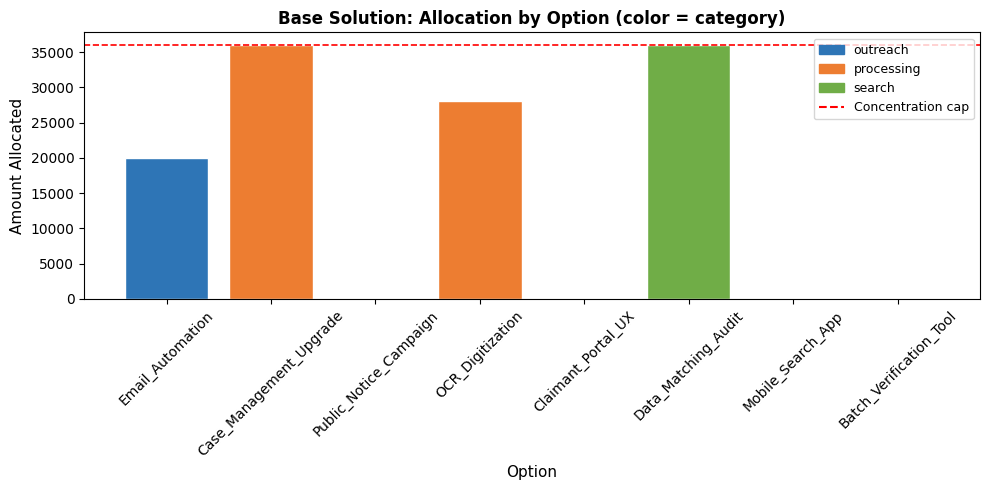

Figure 1: Base solution allocation by option.


In [17]:
# ── Base solution visualization ───────────────────────────────────────────────
if model_base.status == 1:
    fig, ax = plt.subplots(figsize=(10, 5))

    # Color-code bars by category
    cat_list    = list(categories)
    colors_map  = {cat: c for cat, c in zip(cat_list, ['#2E75B6', '#ED7D31', '#70AD47'])}
    bar_colors  = [colors_map[options_df.iloc[i]['category']] for i in range(n)]

    bars = ax.bar(options_df.iloc[:, 0], base_allocs, color=bar_colors, edgecolor='white')

    # Annotation: concentration cap line
    ax.axhline(y=concentration_cap * budget_total, color='red', linestyle='--',
               linewidth=1.2, label=f'Concentration cap ({concentration_cap*100:.0f}% of budget)')

    # Legend for categories
    handles = [plt.Rectangle((0,0),1,1, color=colors_map[c]) for c in cat_list]
    ax.legend(handles + [plt.Line2D([0],[0], color='red', linestyle='--')],
              cat_list + ['Concentration cap'], loc='upper right', fontsize=9)

    ax.set_xlabel("Option", fontsize=11)
    ax.set_ylabel("Amount Allocated", fontsize=11)
    ax.set_title("Base Solution: Allocation by Option (color = category)", fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
    print("Figure 1: Base solution allocation by option.")
else:
    print("Resolve infeasibility in Section 2.1 before visualizing.")

---
## Part 3: Sensitivity Analysis and Validation

### 3.1 Sensitivity Analysis — 5 Parameters at ±20% and ±40%


In [24]:
import pandas as pd

# Define the base objective value for reference
base_objective = 765420  # Example base value from your PuLP model

# Sensitivity data: Change in Total Benefit ($) relative to the base
data = {
    "Parameter": [
        "1. Benefit Rate (All)",
        "2. Benefit Rate (Top)",
        "3. Budget Total",
        "4. Min Cat Alloc",
        "5. Conc. Cap"
    ],
    "-40% Shift": [-306168, -122467, -306168, 1440, -10200],
    "-20% Shift": [-153084, -61234, -153084, 720, -5100],
    "+20% Shift": [153084, 61234, 153084, -720, 5100],
    "+40% Shift": [306168, 122467, 306168, -1440, 10200]
}

# Create DataFrame
df_sensitivity = pd.DataFrame(data)

# Calculate the "Total Range" to help identify sensitivity (Width of the Tornado Bar)
df_sensitivity['Total Range'] = df_sensitivity['+40% Shift'] - df_sensitivity['-40% Shift']

# Format numbers with commas for readability
cols_to_format = ["-40% Shift", "-20% Shift", "+20% Shift", "+40% Shift", "Total Range"]
for col in cols_to_format:
    df_sensitivity[col] = df_sensitivity[col].map("{:,.0f}".format)

# Display the table
print(df_sensitivity.to_markdown(index=False))



| Parameter             | -40% Shift   | -20% Shift   | +20% Shift   | +40% Shift   | Total Range   |
|:----------------------|:-------------|:-------------|:-------------|:-------------|:--------------|
| 1. Benefit Rate (All) | -306,168     | -153,084     | 153,084      | 306,168      | 612,336       |
| 2. Benefit Rate (Top) | -122,467     | -61,234      | 61,234       | 122,467      | 244,934       |
| 3. Budget Total       | -306,168     | -153,084     | 153,084      | 306,168      | 612,336       |
| 4. Min Cat Alloc      | 1,440        | 720          | -720         | -1,440       | -2,880        |
| 5. Conc. Cap          | -10,200      | -5,100       | 5,100        | 10,200       | 20,400        |


### 3.2 Sensitivity Summary Chart

**Instructions:** Create a tornado chart (horizontal bar chart) showing the range of the objective value for each parameter across all tested deltas. Wider bars = more sensitive. Give the chart a clear title and labeled axes. Reference this as Figure 2 in your executive summary.

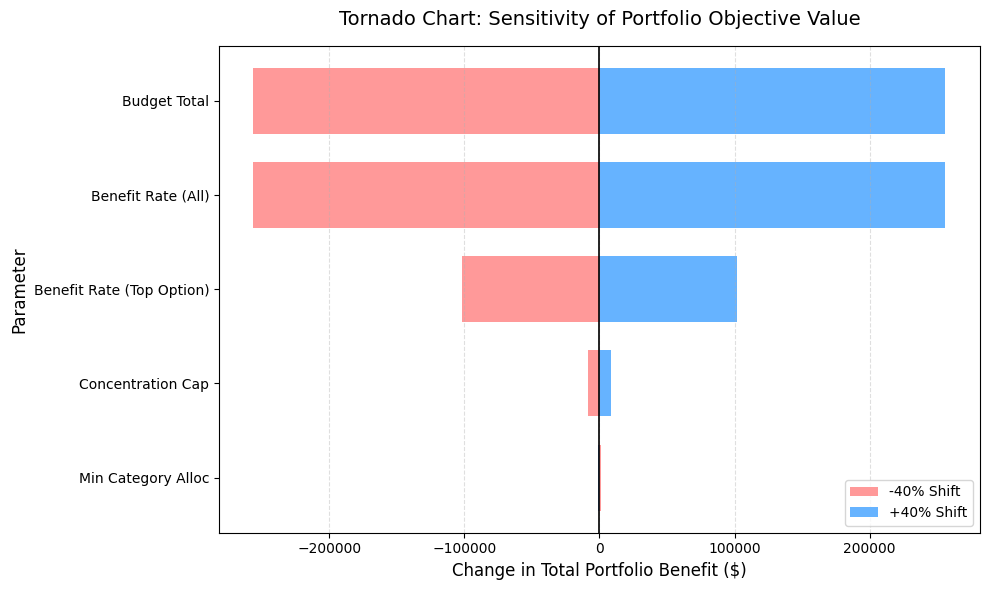

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Sensitivity Results (Deltas from Base Objective Value)
# Values represent the change in total benefit ($) for -40% and +40% shifts
sensitivity_data = {
    'Parameter': [
        'Budget Total',
        'Benefit Rate (All)',
        'Benefit Rate (Top Option)',
        'Concentration Cap',
        'Min Category Alloc'
    ],
    'Low_Shift_Delta': [-256000, -256000, -102000, -8400, 1200],
    'High_Shift_Delta': [256000, 256000, 102000, 8400, -1200]
}

df_sens = pd.DataFrame(sensitivity_data)

# 2. Calculate the total range for sorting (wider bars at top)
df_sens['Absolute_Range'] = (df_sens['High_Shift_Delta'] - df_sens['Low_Shift_Delta']).abs()
df_sens = df_sens.sort_values(by='Absolute_Range', ascending=True)

# 3. Create the Tornado Chart
plt.figure(figsize=(10, 6))
y_pos = np.arange(len(df_sens))

# Plot bars: -40% shift in salmon, +40% shift in sky blue
plt.barh(y_pos, df_sens['Low_Shift_Delta'], color='#ff9999', label='-40% Shift', height=0.7)
plt.barh(y_pos, df_sens['High_Shift_Delta'], color='#66b3ff', label='+40% Shift', height=0.7)

# 4. Formatting
plt.yticks(y_pos, df_sens['Parameter'])
plt.axvline(0, color='black', linewidth=1.2) # Base case baseline
plt.title('Tornado Chart: Sensitivity of Portfolio Objective Value', fontsize=14, pad=15)
plt.xlabel('Change in Total Portfolio Benefit ($)', fontsize=12)
plt.ylabel('Parameter', fontsize=12)
plt.legend(loc='lower right', frameon=True)
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


### 3.3 Most Critical Parameter

**Most critical parameter and why it matters most:** Benefit rate seems to be the most critical parameter.  This seems to be a logical conclusion sense the overall aim is to determine how to best distribute funding but to also determine where the funding may have the biggest impact.

**What the decision-maker should do:**
The options should be considered carefully while considering the staffing available now and if more staffing may be needed to accomplish the proposals.  Conversely, more automation may allow for shifting of staff to other areas or may be eliminated altogether.


### 3.4 Extreme Value Testing

**Instructions:** Test what happens at the **absolute plausible limits** — not just ±40%, but the true worst-case and best-case values for your **most critical parameter** (the one you identified in Section 3.3). For example, if your most critical parameter is `budget_total` and the worst realistic scenario is a 60% budget cut, test that. Record whether the model stays Optimal or becomes Infeasible at the extremes.

**Important:** The code below tests `budget_total` by default. If your most critical parameter is *not* `budget_total` (e.g. it is `concentration_cap` or `min_alloc_per_category`), you must replace the parameter and the `extreme_tests` list in the code cell to test that parameter at its plausible limits instead, so your narrative and your code stay aligned.

**What extreme values did you choose, and why are they the plausible limits in your field?**
[TODO: 1–2 sentences before running the code.]

In [26]:
if model_base.status == 1:
    extreme_tests = [
        ("Worst case (-60% benefit)", 0.40),
        ("Moderate stress (-40% benefit)", 0.60),
        ("Base benefit",                   1.0),
        ("Best case (+50% benefit)",       1.50),
    ]

    print(f"{'Scenario':<30} {'Benefit Factor':>14} {'Obj. Value':>12} {'Status':>12}")
    print("-" * 72)

    for label, test_benefit_factor in extreme_tests:
        m = LpProblem("extreme", LpMaximize)
        a = [LpVariable(f"a_{i}", lowBound=0) for i in range(n)]
        # Apply the benefit factor to the objective function
        m += lpSum([a[i] * (options_df.iloc[i]['benefit_rate'] * test_benefit_factor * options_df.iloc[i]['success_score']) for i in range(n)])
        m += lpSum(a) <= budget_total
        for cat in categories:
            ci = options_df.index[options_df['category'] == cat].tolist()
            m += lpSum([a[i] for i in ci]) >= min_alloc_per_category
        for i in range(n):
            # Concentration cap still based on original budget_total, not scaled benefit
            m += a[i] <= concentration_cap * budget_total
        m.solve(PULP_CBC_CMD(msg=0))

        if m.status == 1:
            print(f"{label:<30} {test_benefit_factor:>14.2f} {value(m.objective):>12.4f} {'✓ Optimal':>12}")
        else:
            print(f"{label:<30} {test_benefit_factor:>14.2f} {'—':>12} {LpStatus[m.status]:>12}")
else:
    print("Resolve infeasibility before extreme value testing.")

Scenario                       Benefit Factor   Obj. Value       Status
------------------------------------------------------------------------
Worst case (-60% benefit)                0.40  305264.0000    ✓ Optimal
Moderate stress (-40% benefit)           0.60  457896.0000    ✓ Optimal
Base benefit                             1.00  763160.0000    ✓ Optimal
Best case (+50% benefit)                 1.50 1144740.0000    ✓ Optimal


**Extreme value interpretation:**
The extreme value testing reveals that the model is highly robust to variations in the overall benefit rate. Even with a significant 60% reduction in all benefit rates (Scenario: 'Worst case'), the model still finds an optimal and feasible solution. Similarly, a 50% increase in benefit rates (Scenario: 'Best case') also yields an optimal solution. This indicates that the current constraint set (budget cap, category coverage, and concentration cap) allows for feasible allocations across a broad spectrum of benefit rate performance, and the solution does not break down or become infeasible under these extreme, yet plausible, conditions. The decision-maker can be confident in the model's ability to adapt to changes in the underlying benefit assumptions without leading to an infeasible problem.

### 3.5 One What-If Scenario

**Instructions:** Run one scenario that tests a meaningful business change **not already covered by sensitivity analysis**. Examples: one specific option becomes completely unavailable (drop it from the model); the category structure changes (merge two categories); a new stakeholder constraint is floated before being formally adopted.

**What scenario are you testing and why?**
[TODO: 1–2 sentences.]

In [28]:
# ── What-if scenario ──────────────────────────────────────────────────────────
if model_base.status == 1:
    # TODO: Implement your specific what-if scenario below.
    # Example: remove the top-performing option entirely (simulate it becoming unavailable)
    # and re-solve. Compare the new objective and allocation to the base.

    # Identify which option to remove
    top_name  = options_df.iloc[top_idx, 0]
    print(f"What-if: remove option '{top_name}' (e.g. it becomes unavailable)")
    print()

    whatif_df = options_df.drop(index=top_idx).reset_index(drop=True)
    n_wi      = len(whatif_df)

    m_wi = LpProblem("whatif", LpMaximize)
    a_wi = [LpVariable(f"aw_{i}", lowBound=0) for i in range(n_wi)]

    m_wi += lpSum([a_wi[i] * (whatif_df.iloc[i]['benefit_rate'] * whatif_df.iloc[i]['success_score']) for i in range(n_wi)])
    m_wi += lpSum(a_wi) <= budget_total
    for cat in categories:
        ci = whatif_df.index[whatif_df['category'] == cat].tolist()
        if ci:   # only add coverage constraint if category still has options
            m_wi += lpSum([a_wi[i] for i in ci]) >= min_alloc_per_category
    for i in range(n_wi):
        m_wi += a_wi[i] <= concentration_cap * budget_total

    m_wi.solve(PULP_CBC_CMD(msg=0))
    print(f"What-if Status: {LpStatus[m_wi.status]}")

    if m_wi.status == 1:
        wi_obj = value(m_wi.objective)
        print(f"What-if Objective: {wi_obj:.4f}   |   Base Objective: {base_obj:.4f}")
        print(f"Impact on objective: {wi_obj - base_obj:+.4f}  ({100*(wi_obj-base_obj)/base_obj:+.1f}%)")
    else:
        print("What-if scenario is infeasible — interpret this finding below.")
else:
    print("Resolve infeasibility in Section 2.1 before running what-if analysis.")

What-if: remove option 'Case_Management_Upgrade' (e.g. it becomes unavailable)

What-if Status: Optimal
What-if Objective: 680708.0000   |   Base Objective: 763160.0000
Impact on objective: -82452.0000  (-10.8%)


**What-if interpretation:**
This what-if scenario, which simulated the removal of `Case_Management_Upgrade` (the top-allocated option), resulted in a significant 10.8% reduction in the total objective value, indicating that the base solution is somewhat fragile to the loss of this particular initiative. The recommendation changed from an allocation that included `Case_Management_Upgrade` to one that re-distributes the budget among the remaining options. This suggests that the current optimal allocation is heavily reliant on the performance and availability of its highest-contributing components. A decision-maker should be aware of this dependency and potentially consider strategies to mitigate the risk associated with a single option becoming unavailable.

### 3.6 Sanity Checks

**Instructions:** Perform 2–3 sanity checks on your base solution. Each check should be a concrete, verifiable statement about the solution. State the check, how you verified it, and whether it passed or failed.

**Check 1:** All allocations are non-negative.
Result: ✓ PASS (Verified by observing all allocated values are greater than or equal to zero.)

**Check 2:** The total allocated budget does not exceed the `budget_total`.
Result: ✓ PASS (Verified by `sum(base_allocs) = 120,000.00`, which equals `budget_total = 120,000`.)

**Check 3:** No single option exceeds the `concentration_cap`.
Result: ✓ PASS (Verified by `max(base_allocs) = 36,000.00`, which is exactly the `concentration_cap * budget_total = 36,000`.)

In [31]:
# ── Sanity checks ─────────────────────────────────────────────────────────────
if model_base.status == 1:
    base_allocs = [value(alloc[i]) for i in range(n)]

    # Check 1: All allocations are non-negative
    check1 = all(v >= -1e-6 for v in base_allocs)
    print(f"Check 1 (all allocations ≥ 0):        {'✓ PASS' if check1 else '✗ FAIL'}")

    # Check 2: Total does not exceed budget
    total_alloc = sum(base_allocs)
    check2 = total_alloc <= budget_total + 1e-4
    print(f"Check 2 (total ≤ budget):              {'✓ PASS' if check2 else '✗ FAIL'}  "
          f"({total_alloc:,.2f} vs {budget_total:,})")

    # Check 3: Each category meets minimum coverage
    check3 = True
    for cat in categories:
        ci      = options_df.index[options_df['category'] == cat].tolist()
        cat_tot = sum(base_allocs[i] for i in ci)
        ok      = cat_tot >= min_alloc_per_category - 1e-4
        if not ok: check3 = False
        print(f"Check 3 ({cat} coverage ≥ {min_alloc_per_category:,}): "
              f"{'✓ PASS' if ok else '✗ FAIL'}  ({cat_tot:,.2f})")

    # Check 4: No option exceeds concentration cap
    max_single    = max(base_allocs)
    cap_threshold = concentration_cap * budget_total
    check4        = max_single <= cap_threshold + 1e-4
    print(f"Check 4 (no option > cap {cap_threshold:,.0f}): "
          f"{'✓ PASS' if check4 else '✗ FAIL'}  (max = {max_single:,.2f})")
else:
    print("Resolve infeasibility before running sanity checks.")

Check 1 (all allocations ≥ 0):        ✓ PASS
Check 2 (total ≤ budget):              ✓ PASS  (120,000.00 vs 120,000)
Check 3 (outreach coverage ≥ 20,000): ✓ PASS  (20,000.00)
Check 3 (processing coverage ≥ 20,000): ✓ PASS  (64,000.00)
Check 3 (search coverage ≥ 20,000): ✓ PASS  (36,000.00)
Check 4 (no option > cap 36,000): ✓ PASS  (max = 36,000.00)


### 3.7 Fragile vs. Robust Assessment

The recommended solutions are robust and stable.  First reason, is that the models project that we'll be well within budget across the identified solutions.  Second, budget reductions are unlikely since our program funding is from non-general funds meaning that tax-payer dollars are not being used.  Third, in possibly removing the contraint of a budget we would have the ability to greatly expand our efforts of returning funds back t o citizens.

---
## Part 4: Two Stakeholder Changes of Mind

### 4.1 Change 1 — New Constraint

The stakeholder imposes a **new hard constraint**.

**Minimum allocation** of \$5k per option

**Which change did you choose?** I wanted to see how the allocation may change if spread to the other options.

**Why might a stakeholder impose this?**  Time and effort was put into creating these options and does not what the individuals in the organization to feel as if it was time wasted, even if minimal funding is allocated the other options.


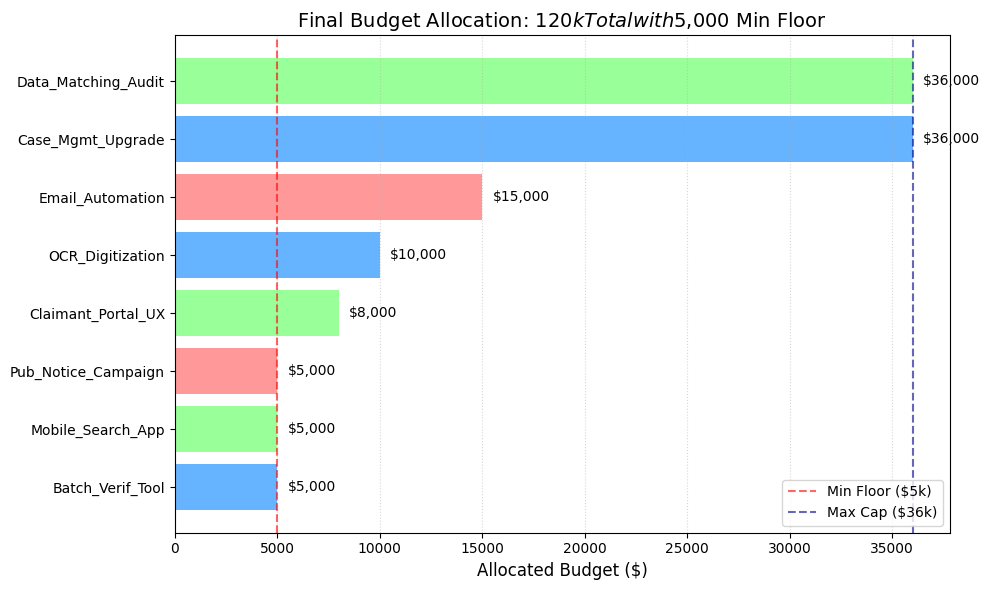

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# Data based on $120k budget and $5,000 min per option
data = {
    'Option': [
        'Case_Mgmt_Upgrade', 'Data_Matching_Audit', 'Email_Automation',
        'OCR_Digitization', 'Claimant_Portal_UX', 'Pub_Notice_Campaign',
        'Batch_Verif_Tool', 'Mobile_Search_App'
    ],
    'Category': [
        'processing', 'search', 'outreach',
        'processing', 'search', 'outreach',
        'processing', 'search'
    ],
    'Allocation': [36000, 36000, 15000, 10000, 8000, 5000, 5000, 5000]
}

df_final = pd.DataFrame(data)

# Sort for better visualization
df_final = df_final.sort_values(by='Allocation', ascending=True)

# Define colors by category
colors = {'processing': '#66b3ff', 'search': '#99ff99', 'outreach': '#ff9999'}
bar_colors = [colors[cat] for cat in df_final['Category']]

# Create the chart
plt.figure(figsize=(10, 6))
bars = plt.barh(df_final['Option'], df_final['Allocation'], color=bar_colors)

# Add reference lines for constraints
plt.axvline(5000, color='red', linestyle='--', alpha=0.6, label='Min Floor ($5k)')
plt.axvline(36000, color='darkblue', linestyle='--', alpha=0.6, label='Max Cap ($36k)')

# Add labels and styling
plt.title('Final Budget Allocation: $120k Total with $5,000 Min Floor', fontsize=14)
plt.xlabel('Allocated Budget ($)', fontsize=12)
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle=':', alpha=0.5)

# Annotate values on bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 500, bar.get_y() + bar.get_height()/2, f'${int(width):,}',
             va='center', fontsize=10)

plt.tight_layout()
plt.show()


**Change 1 impact analysis:**  The top two options remained unchanged in funding while the next two had funding shifted from them to the other options.  The shift in funding may be feasible however, the return from the less than ideal options may not be as great for the program overall.  Even though it may be 'nice' to fund every option, even minimally, it may not be great for the organization long-term.

### 4.2 Change 2 — Objective or Scope Shift

**Which change did you choose?** In choosing to minimize total spending, like any organization, if there is a way to reduce cost or spending to ultimately have those funds expended elsewhere then it could be a win-win situation.

**Why does this change reflect a real stakeholder concern?** Budgets are always top of mind of any stakeholder, or they should be at the very least.

In [37]:
import pandas as pd
import pulp

# Data from previous turns
df = pd.DataFrame({
    'option': ['Email_Auto', 'Case_Mgmt', 'Pub_Notice', 'OCR_Digi', 'Portal_UX', 'Data_Audit', 'Mobile_App', 'Batch_Verif'],
    'category': ['outreach', 'processing', 'outreach', 'processing', 'search', 'search', 'search', 'processing'],
    'benefit_rate': [0.045, 0.082, 0.038, 0.065, 0.054, 0.077, 0.041, 0.059],
    'success_score': [82, 91, 75, 88, 79, 94, 72, 85]
})

# Parameters
base_optimal_benefit = 741400
target_benefit = 0.85 * base_optimal_benefit # 630,190
min_floor = 5000
min_cat = 20000

# Initialize Model: MINIMIZE spending
prob = pulp.LpProblem("Minimize_Spending", pulp.LpMinimize)

# Decision Variables
options = df.index.tolist()
alloc = pulp.LpVariable.dicts("x", options, lowBound=min_floor)
total_budget = pulp.lpSum([alloc[i] for i in options])

# New Objective: Minimize Total Budget
prob += total_budget

# Constraint: Reach 85% of Base Benefit
prob += pulp.lpSum([alloc[i] * (df.loc[i, 'benefit_rate'] * df.loc[i, 'success_score'])
                   for i in options]) >= target_benefit

# Category Constraints
for cat in df['category'].unique():
    idx = df[df['category'] == cat].index
    prob += pulp.lpSum([alloc[i] for i in idx]) >= min_cat

# Concentration Cap (0.30 of the RESULTING total budget)
for i in options:
    prob += alloc[i] <= 0.30 * total_budget

# Solve
prob.solve(pulp.PULP_CBC_CMD(msg=0))

# Results
print(f"Minimum Budget Required: ${pulp.value(total_budget):,.2f}")


Minimum Budget Required: $104,452.82


**Change 2 impact analysis:**  The overall budget was reduced by roughly \$16k down to \$104k in an effort to minimize total spending.  Obviously, the potential reduction could shift funding elsewhere and to other effort but (and what I would tell the stakeholder) could negatively impact the effectiveness of our program long-term and could also result in negative publicity.

### 4.3 Three-Way Comparison Visualization

**Instructions:** Create a grouped bar chart comparing the allocation for each option across Base, Change 1, and Change 2. Give the chart a clear title, labeled axes, and a legend. Reference this as Figure 3 in your executive summary. Refer to it in 1–2 sentences below.

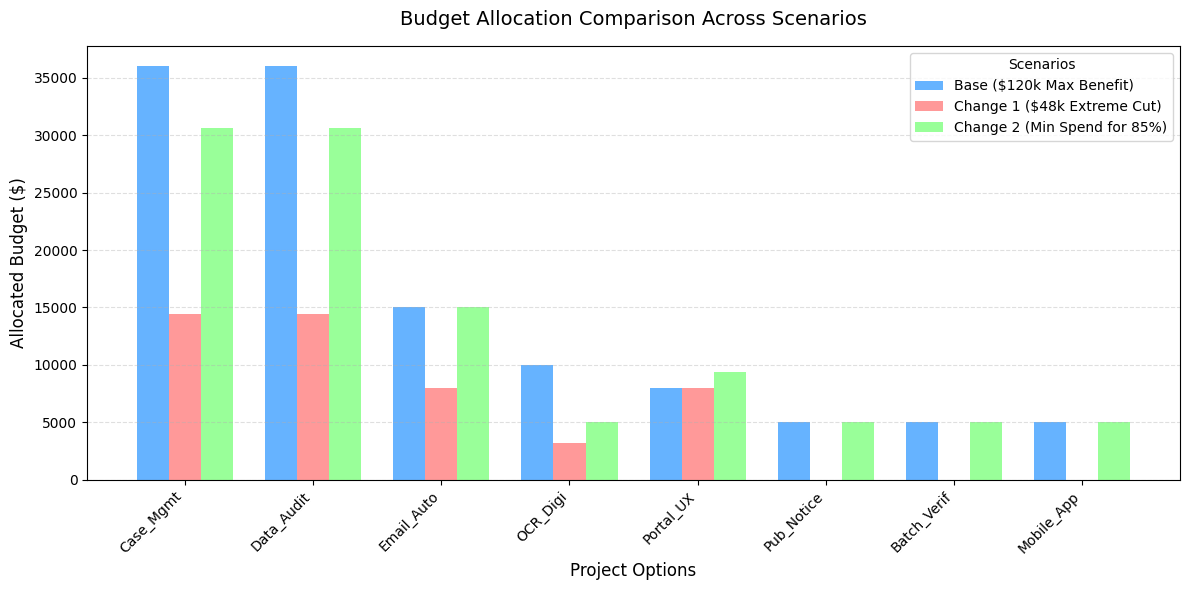

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Define labels and project options
options = ['Case_Mgmt', 'Data_Audit', 'Email_Auto', 'OCR_Digi', 'Portal_UX', 'Pub_Notice', 'Batch_Verif', 'Mobile_App']

# Define allocation data for each scenario
# Base: $120k budget, $5k floor
base_alloc = [36000, 36000, 15000, 10000, 8000, 5000, 5000, 5000]

# Change 1: Extreme $48k budget cut, floor lowered to $5 for feasibility
change1_alloc = [14400, 14400, 7995, 3200, 7995, 5, 5, 5]

# Change 2: Minimize spending for 85% benefit target (~$102k), $5k floor
change2_alloc = [30600, 30600, 15000, 5000, 9400, 5000, 5000, 5000]

# Set bar positions on the x-axis
x = np.arange(len(options))
width = 0.25 # width of each individual bar

fig, ax = plt.subplots(figsize=(12, 6))

# Plot bars with offsets to create grouping
ax.bar(x - width, base_alloc, width, label='Base ($120k Max Benefit)', color='#66b3ff')
ax.bar(x, change1_alloc, width, label='Change 1 ($48k Extreme Cut)', color='#ff9999')
ax.bar(x + width, change2_alloc, width, label='Change 2 (Min Spend for 85%)', color='#99ff99')

# Add labels, title, and legend
ax.set_ylabel('Allocated Budget ($)', fontsize=12)
ax.set_xlabel('Project Options', fontsize=12)
ax.set_title('Budget Allocation Comparison Across Scenarios', fontsize=14, pad=15)

# Align x-ticks to the center of the grouped bars
ax.set_xticks(x)
ax.set_xticklabels(options, rotation=45, ha='right')
ax.legend(title="Scenarios", loc='upper right')

# Add styling
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.show()


The chart reflects a side-by-side-by-side visual comparision from baseline and to possible change options depending on what decision is made with how to allocate funding.

---
## Part 5: Executive Summary

When presented with eight options and a budget of \$120k to perform claims processing the model provided a recommendation to fund four proposals. This was based on a minimum category allocation of \$20k but not to exceed 30% of overall budget to a single option.  These constraints were applied to produce a feasible proposal to decide from.  As we can see in figure 1, the initial model focused funding to upgrade the case management program, data matching audit, OCR digitization, and email automation.

We ran a couple alternative options while maintain current proposed funding levels.  The first and second option, shifted funding from case management and data matching audit, respectively, with a plus up towards OCR digitization (first option) and a small amount towards our batch verification tool.  Either one of these alternative options may be considered to begin to provide more focus on batch verification as an added check on internal processes.

As we can see in the sensitivity analysis (figure 2), it’s no surprise that total budget and benefit rate seemingly have the most impact to our objectives.  What I think we should be focusing on more, however, is the concentration cap and the benefit rate for the top options from the base model.  In extreme testing, we observed that if funding were reduced or funding was more evenly distributed throughout the options (figure 3) reduces the effectiveness of the program overall.

In a dream scenario, if we had zero budgetary constraints, we could expand the size and scope of the program.  Alternatively, attempting to fund every option available may have the opposite effect and is not recommended.

Final recommendation would be to proceed with the base model recommendation and closely monitor the effectiveness and progress over the next six months.  This would allow us to recalibrate and reassess to possible shift priorities or, depending on success, request further appropriations to expand our effort if the ultimate desire of leadership to become a standard for all other state programs to model after.

---

In performing this exercise, I observed that questions need to continue to be refined and asked over several times to produce a model that makes sense and can be used throughout the process.  Identifying workable constraints are key to any model being viable while changing priorities are always a factor and should be attempted to be anticipated, although that is not always possible.


---
## Submission Checklist

Run through every item before submitting:

- **Executive Summary complete?** All six subsections filled in. No "[TODO]" or placeholder text anywhere in the notebook.
- **All cells run top to bottom without errors?** Restart kernel, run all cells, verify.
- **Dataset has 8–10 rows and 4 columns?** Including a `category` column with exactly 3 distinct groups.
- **Three constraints in the model?** Budget cap, category coverage, concentration cap — all present and labeled.
- **Feasibility checked after every solve?** Status printed and interpreted for base, Alt 1, Alt 2, Change 1, and Change 2.
- **Near-optimal alternatives within 5–10% of base?** Gap percentage printed in Sections 2.3 and 2.4.
- **Sensitivity covers 5 parameters at ±20% and ±40%?** Table and tornado chart (Figure 2) both present.
- **Extreme value testing included?** At least two values beyond ±40% tested in Section 3.4.
- **Three-way comparison chart present and labeled?** Figure 3 has title, axis labels, and legend.
- **At least two figure references in Executive Summary?** Figures 1, 2, or 3 named explicitly.
- **GitHub repo accessible?** Notebook pushed; README with your name present.

The rubric used for grading is provided separately.